In [108]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [109]:
# 데이터 불러오기
df = pd.read_csv("C:\\Users\\user\\Desktop\\pg\\CUAI\\basic_dacon\\open\\train.csv")
test_df = pd.read_csv("C:\\Users\\user\\Desktop\\pg\\CUAI\\basic_dacon\\open\\test.csv")
df.head(5)

,ID,설립연도,국가,분야,투자단계,직원 수,인수여부,상장여부,고객수(백만명),총 투자금(억원),연매출(억원),SNS 팔로워 수(백만명),기업가치(백억원),성공확률
0,TRAIN_0000,2009,CT005,이커머스,Series A,4126.0,No,No,56.0,3365.0,4764.0,4.71,NaN,0.3
1,TRAIN_0001,2023,CT006,핀테크,Seed,4167.0,Yes,No,80.0,4069.0,279.0,1.00,2500-3500,0.8
2,TRAIN_0002,2018,CT007,기술,Series A,3132.0,Yes,Yes,54.0,6453.0,12141.0,4.00,3500-4500,0.5
3,TRAIN_0003,2016,CT006,NaN,Seed,3245.0,Yes,Yes,NaN,665.0,10547.0,2.97,NaN,0.7
4,TRAIN_0004,2020,CT002,에듀테크,Seed,1969.0,No,Yes,94.0,829.0,9810.0,1.00,1500-2500,0.1


### 간단한 EDA 진행

In [110]:
# 1. 데이터 크기 확인
print("데이터 크기:", df.shape)

데이터 크기: (4376, 14)


In [111]:
# 2. 기본 정보 확인
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4376 entries, 0 to 4375
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   ID              4376 non-null   object 
 1   설립연도            4376 non-null   int64  
 2   국가              4376 non-null   object 
 3   분야              3519 non-null   object 
 4   투자단계            4376 non-null   object 
 5   직원 수            4202 non-null   float64
 6   인수여부            4376 non-null   object 
 7   상장여부            4376 non-null   object 
 8   고객수(백만명)        3056 non-null   float64
 9   총 투자금(억원)       4376 non-null   float64
 10  연매출(억원)         4376 non-null   float64
 11  SNS 팔로워 수(백만명)  4376 non-null   float64
 12  기업가치(백억원)       3156 non-null   object 
 13  성공확률            4376 non-null   float64
dtypes: float64(6), int64(1), object(7)
memory usage: 478.8+ KB


In [112]:
# 3. 기초 통계량 확인
print(df.describe())

              설립연도         직원 수     고객수(백만명)    총 투자금(억원)       연매출(억원)  \
count  4376.000000  4202.000000  3056.000000  4376.000000   4376.000000   
mean   2012.006856  2471.324369    49.214332  3314.568556   6452.202239   
std       6.554872  1446.064215    27.141242  1880.103831   3782.792656   
min    2001.000000     5.000000     1.000000    12.000000     12.000000   
25%    2006.000000  1218.250000    27.000000  1651.500000   3094.250000   
50%    2012.000000  2472.000000    49.000000  3398.000000   6478.500000   
75%    2018.000000  3727.500000    72.000000  4908.250000   9692.500000   
max    2023.000000  4998.000000    99.000000  7059.000000  14822.000000   

       SNS 팔로워 수(백만명)         성공확률  
count     4376.000000  4376.000000  
mean         2.578103     0.537340  
std          1.414590     0.241698  
min          0.000000     0.100000  
25%          1.320000     0.400000  
50%          2.835000     0.600000  
75%          4.000000     0.700000  
max          5.000000     0.

In [113]:
# 4. 결측치 개수 확인
print("\n결측치 개수:\n", df.isnull().sum())


결측치 개수:
 ID                   0
설립연도                 0
국가                   0
분야                 857
투자단계                 0
직원 수               174
인수여부                 0
상장여부                 0
고객수(백만명)          1320
총 투자금(억원)            0
연매출(억원)              0
SNS 팔로워 수(백만명)       0
기업가치(백억원)         1220
성공확률                 0
dtype: int64


In [114]:
# 한글 폰트 정상 출력을 위한 설정
import matplotlib.font_manager as fm
import matplotlib as mpl

mpl.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

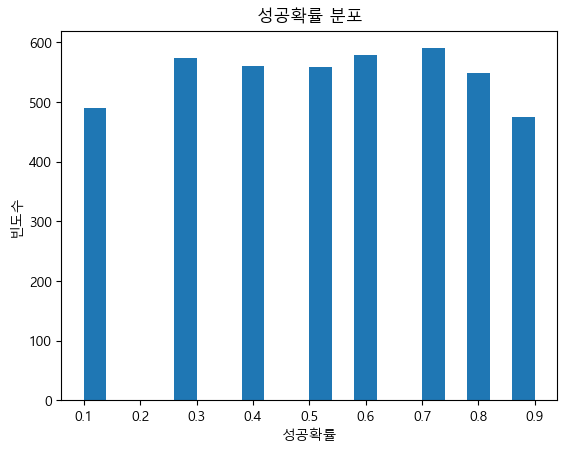

In [115]:
# 5. 목표 변수('성공확률')의 분포 시각화

plt.hist(df['성공확률'], bins=20)
plt.title('성공확률 분포')
plt.xlabel('성공확률')
plt.ylabel('빈도수')
plt.show()

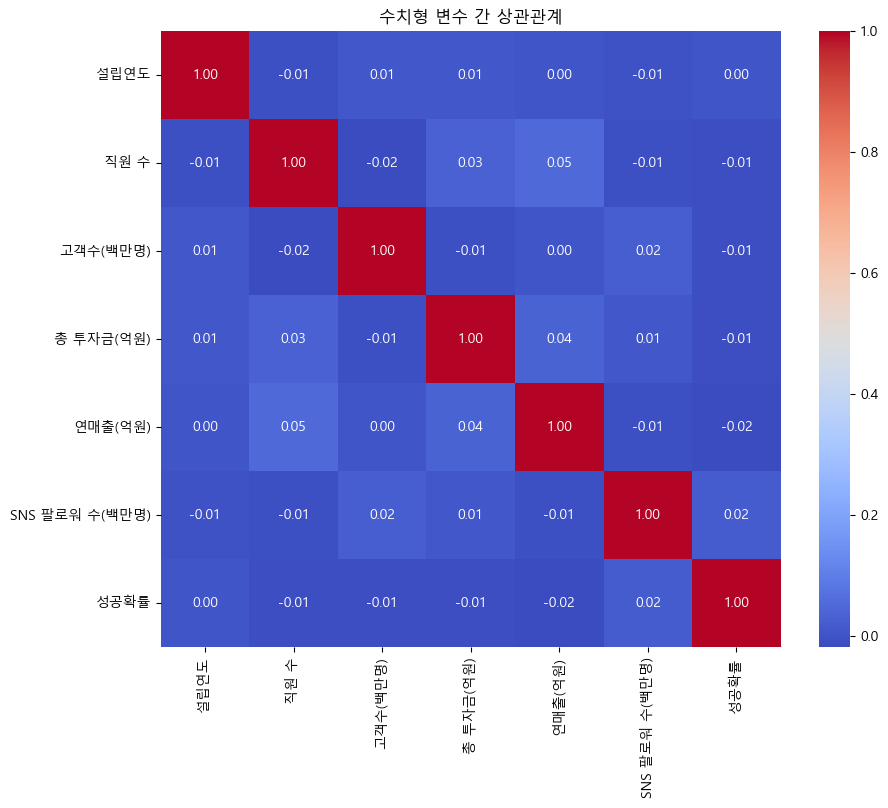

In [116]:
import warnings
warnings.filterwarnings("ignore")
# 6. 수치형 변수 간 상관관계
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(numeric_only=True), annot=True, fmt=".2f", cmap="coolwarm")
plt.title('수치형 변수 간 상관관계')
plt.show()

### 전처리  

In [117]:
# 1. 'ID' 칼럼 삭제
df.drop(columns=['ID'], inplace=True)
test_df.drop(columns=['ID'], inplace=True)

In [118]:
# 2. '분야' 칼럼 결측치 'Unknown' 처리
df['분야'] = df['분야'].fillna('Unknown')
test_df['분야'] = df['분야'].fillna('Unknown')

In [119]:
# 3. '직원 수', '고객수(백만명)' 칼럼 결측치 'median' 대체
for col in ['직원 수', '고객수(백만명)']:
    median_val = df[col].median()
    df[col] = df[col].fillna(median_val)

for col in ['직원 수', '고객수(백만명)']:
    median_val = test_df[col].median()
    test_df[col] = test_df[col].fillna(median_val)

In [120]:
# 4. '기업가치' 칼럼 전처리

# 범주형 칼럼 '기업가치'를 하한값으로 변환하는 함수
def convert_to_lower_limit(value):

    # 값이 NaN이면 그대로 반환
    if pd.isna(value):
        return np.nan

    # 값이 '문자열'이면 특수 문자 '-' 포함 여부 확인
    if isinstance(value, str):

        # 값이 '6000이상' -> 6000.0으로 변환
        if value == '6000이상':
            return 6000.0

        # 값이 특수 문자 '-' 포함한 범주형 -> 하한값('-' 앞의 값)만 추출
        if '-' in value:
            return float(value.split('-')[0])

        # 값이 '-'없이 숫자만 문자열 형태로 있는 경우 -> float 변환
        return float(value)

    return value

# 함수 적용
df['기업가치(백억원)'] = df['기업가치(백억원)'].apply(convert_to_lower_limit)

# 남은 결측치(NaN) -> 전체의 중앙값(median)으로 대체
df['기업가치(백억원)'] = df['기업가치(백억원)'].fillna(df['기업가치(백억원)'].median())

def convert_to_lower_limit(value):

    # 값이 NaN이면 그대로 반환
    if pd.isna(value):
        return np.nan

    # 값이 '문자열'이면 특수 문자 '-' 포함 여부 확인
    if isinstance(value, str):

        # 값이 '6000이상' -> 6000.0으로 변환
        if value == '6000이상':
            return 6000.0

        # 값이 특수 문자 '-' 포함한 범주형 -> 하한값('-' 앞의 값)만 추출
        if '-' in value:
            return float(value.split('-')[0])

        # 값이 '-'없이 숫자만 문자열 형태로 있는 경우 -> float 변환
        return float(value)

    return value

# 함수 적용
test_df['기업가치(백억원)'] = test_df['기업가치(백억원)'].apply(convert_to_lower_limit)

# 남은 결측치(NaN) -> 전체의 중앙값(median)으로 대체
test_df['기업가치(백억원)'] = test_df['기업가치(백억원)'].fillna(test_df['기업가치(백억원)'].median())

In [121]:
# 5. 범주형 데이터 처리
from sklearn.preprocessing import LabelEncoder

# '인수여부', '상장여부' -> Label Encoding
label_cols = ['인수여부', '상장여부']
for col in label_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])

# '국가', '분야', '투자단계' -> One - Hot Encoding
onehot_cols = ['국가', '분야', '투자단계']
df = pd.get_dummies(df, columns=onehot_cols)

# '인수여부', '상장여부' -> Label Encoding
label_cols = ['인수여부', '상장여부']
for col in label_cols:
    le = LabelEncoder()
    test_df[col] = le.fit_transform(test_df[col])

# '국가', '분야', '투자단계' -> One - Hot Encoding
onehot_cols = ['국가', '분야', '투자단계']
test_df = pd.get_dummies(test_df, columns=onehot_cols)

In [122]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4376 entries, 0 to 4375
Data columns (total 36 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   설립연도            4376 non-null   int64  
 1   직원 수            4376 non-null   float64
 2   인수여부            4376 non-null   int32  
 3   상장여부            4376 non-null   int32  
 4   고객수(백만명)        4376 non-null   float64
 5   총 투자금(억원)       4376 non-null   float64
 6   연매출(억원)         4376 non-null   float64
 7   SNS 팔로워 수(백만명)  4376 non-null   float64
 8   기업가치(백억원)       4376 non-null   float64
 9   성공확률            4376 non-null   float64
 10  국가_CT001        4376 non-null   bool   
 11  국가_CT002        4376 non-null   bool   
 12  국가_CT003        4376 non-null   bool   
 13  국가_CT004        4376 non-null   bool   
 14  국가_CT005        4376 non-null   bool   
 15  국가_CT006        4376 non-null   bool   
 16  국가_CT007        4376 non-null   bool   
 17  국가_CT008        4376 non-null   b

In [123]:
test_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1755 entries, 0 to 1754
Data columns (total 35 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   설립연도            1755 non-null   int64  
 1   직원 수            1755 non-null   float64
 2   인수여부            1755 non-null   int32  
 3   상장여부            1755 non-null   int32  
 4   고객수(백만명)        1755 non-null   float64
 5   총 투자금(억원)       1755 non-null   float64
 6   연매출(억원)         1755 non-null   float64
 7   SNS 팔로워 수(백만명)  1755 non-null   float64
 8   기업가치(백억원)       1755 non-null   float64
 9   국가_CT001        1755 non-null   bool   
 10  국가_CT002        1755 non-null   bool   
 11  국가_CT003        1755 non-null   bool   
 12  국가_CT004        1755 non-null   bool   
 13  국가_CT005        1755 non-null   bool   
 14  국가_CT006        1755 non-null   bool   
 15  국가_CT007        1755 non-null   bool   
 16  국가_CT008        1755 non-null   bool   
 17  국가_CT009        1755 non-null   b

In [124]:
numeric_cols = df.select_dtypes(include='number').columns
# 이상치 확인
outlier_summary = []

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    outlier_summary.append({
        "Feature": col,
        "Q1": round(Q1, 2),
        "Q3": round(Q3, 2),
        "IQR": round(IQR, 2),
        "LowerBound": round(lower, 2),
        "UpperBound": round(upper, 2),
        "OutlierCount": len(outliers)
    })

outlier_df = pd.DataFrame(outlier_summary)
outlier_df.sort_values(by="OutlierCount", ascending=False)

,Feature,Q1,Q3,IQR,LowerBound,UpperBound,OutlierCount
0,설립연도,2006.00,2018.00,12.00,1988.00,2036.00,0
1,직원 수,1272.00,3675.25,2403.25,-2332.88,7280.12,0
2,인수여부,0.00,1.00,1.00,-1.50,2.50,0
3,상장여부,0.00,1.00,1.00,-1.50,2.50,0
4,고객수(백만명),37.00,62.00,25.00,-0.50,99.50,0
5,총 투자금(억원),1651.50,4908.25,3256.75,-3233.62,9793.38,0
6,연매출(억원),3094.25,9692.50,6598.25,-6803.12,19589.88,0
7,SNS 팔로워 수(백만명),1.32,4.00,2.68,-2.70,8.02,0
8,기업가치(백억원),2500.00,4500.00,2000.00,-500.00,7500.00,0
9,성공확률,0.40,0.70,0.30,-0.05,1.15,0


In [125]:
# 음수가 나오면 안 되는 주요 변수 리스트
columns_to_check = [
    '직원 수', '고객수(백만명)', '총 투자금(억원)', '연매출(억원)',
    'SNS 팔로워 수(백만명)', '기업가치(백억원)'
]

# 변수별로 음수값 존재 여부 확인
for col in columns_to_check:
    negative_count = (df[col] < 0).sum()
    print(f"{col}: {negative_count} rows with negative values")


직원 수: 0 rows with negative values
고객수(백만명): 0 rows with negative values
총 투자금(억원): 0 rows with negative values
연매출(억원): 0 rows with negative values
SNS 팔로워 수(백만명): 0 rows with negative values
기업가치(백억원): 0 rows with negative values


**이상치도 딱히 없고, 음수 값 데이터도 없어서 이상치는 특별히 처리하지 않도록 하겠습니다**

In [126]:
# 기준 연도 설정
CURRENT_YEAR = 2025

# 업력 파생변수 생성 (한글 컬럼명 기준) (업력: 쉽게 말해 기업의 나이)
df['업력'] = CURRENT_YEAR - df['설립연도'] + 1
test_df['업력'] = CURRENT_YEAR - test_df['설립연도'] + 1

In [127]:
# 작은 수 ε 설정 (0으로 나누는 것 방지)
epsilon = 1e-5


In [128]:
# 매출대비투자비율 생성
epsilon = 1e-5
df['매출대비투자비율'] = df['연매출(억원)'] / (df['총 투자금(억원)'] + epsilon)

# 성공확률 기준 그룹 나누기
threshold = 0.7
high = df[df['성공확률'] > threshold]['매출대비투자비율']
low = df[df['성공확률'] <= threshold]['매출대비투자비율']

# Mann-Whitney U test
from scipy.stats import mannwhitneyu
stat, p = mannwhitneyu(high, low, alternative='two-sided')

print(f"U 통계량: {stat:.2f}")
print(f"p-value: {p:.5f}")

if p < 0.05:
    print("✅ 통계적으로 유의한 차이가 있음 (파생변수 의미 있음)")
else:
    print("⚠️ 통계적으로 유의하지 않음 (파생변수 의미 약함)")
# 매출대비투자비율 생성
epsilon = 1e-5
test_df['매출대비투자비율'] = test_df['연매출(억원)'] / (test_df['총 투자금(억원)'] + epsilon)

# Mann-Whitney U test
from scipy.stats import mannwhitneyu
stat, p = mannwhitneyu(high, low, alternative='two-sided')

print(f"U 통계량: {stat:.2f}")
print(f"p-value: {p:.5f}")

if p < 0.05:
    print("✅ 통계적으로 유의한 차이가 있음 (파생변수 의미 있음)")
else:
    print("⚠️ 통계적으로 유의하지 않음 (파생변수 의미 약함)")

U 통계량: 1711294.00
p-value: 0.91523
⚠️ 통계적으로 유의하지 않음 (파생변수 의미 약함)
U 통계량: 1711294.00
p-value: 0.91523
⚠️ 통계적으로 유의하지 않음 (파생변수 의미 약함)


In [129]:
# 기업가치 성장 속도 파생변수 생성
epsilon = 1e-5
df['기업가치성장속도'] = df['기업가치(백억원)'] / (df['업력'] + epsilon)

# 고성공 vs 저성공 그룹 분리
threshold = 0.7
high_group = df[df['성공확률'] > threshold]['기업가치성장속도']
low_group = df[df['성공확률'] <= threshold]['기업가치성장속도']

# Mann-Whitney U test
stat, p = mannwhitneyu(high_group, low_group, alternative='two-sided')

# 결과 출력
print(f"U 통계량: {stat:.2f}")
print(f"p-value: {p:.5f}")

if p < 0.05:
    print("✅ 통계적으로 유의한 차이가 있음 (파생변수 의미 있음)")
else:
    print("⚠️ 통계적으로 유의하지 않음 (파생변수 의미 약함)")

# 기업가치 성장 속도 파생변수 생성
epsilon = 1e-5
test_df['기업가치성장속도'] = test_df['기업가치(백억원)'] / (test_df['업력'] + epsilon)

# Mann-Whitney U test
stat, p = mannwhitneyu(high_group, low_group, alternative='two-sided')

# 결과 출력
print(f"U 통계량: {stat:.2f}")
print(f"p-value: {p:.5f}")

if p < 0.05:
    print("✅ 통계적으로 유의한 차이가 있음 (파생변수 의미 있음)")
else:
    print("⚠️ 통계적으로 유의하지 않음 (파생변수 의미 약함)")

U 통계량: 1700874.00
p-value: 0.68837
⚠️ 통계적으로 유의하지 않음 (파생변수 의미 약함)
U 통계량: 1700874.00
p-value: 0.68837
⚠️ 통계적으로 유의하지 않음 (파생변수 의미 약함)


# RandomForestRegressor 진행

In [130]:
#RandomForesrRegressor 불러오기
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')
# 파생변수 둘 다 있는 경우
y_target = df['성공확률']
X_data = df.drop(['성공확률'], axis = 1)

In [131]:
rf_reg = RandomForestRegressor(n_estimators=1000, min_samples_split=2, min_samples_leaf=1, max_depth=8, random_state=42, n_jobs=-1)
rf_reg.fit(X_data, y_target)
pred_rf = rf_reg.predict(test_df)

In [132]:
submission = pd.read_csv("C:\\Users\\user\\Desktop\\pg\\CUAI\\basic_dacon\\open\\sample_submission.csv")
submission['성공확률'] = pred_rf
submission.to_csv('dacon_all_ft.csv', index=False, encoding='utf-8-sig')

In [133]:
# 파생변수 없는 경우
y_target = df['성공확률']
X1_data = df.drop(['성공확률', '매출대비투자비율', '기업가치성장속도'], axis = 1)
test1_df = test_df.drop(['매출대비투자비율', '기업가치성장속도'], axis = 1)
rf_reg = RandomForestRegressor(n_estimators=1000, min_samples_split=2, min_samples_leaf=1, max_depth=8, random_state=42, n_jobs=-1)
rf_reg.fit(X1_data, y_target)
pred_rf = rf_reg.predict(test1_df)

In [134]:
submission = pd.read_csv("C:\\Users\\user\\Desktop\\pg\\CUAI\\basic_dacon\\open\\sample_submission.csv")
submission['성공확률'] = pred_rf
submission.to_csv('dacon_noft.csv', index=False)

In [135]:
# 파생변수 기업가치성장속도만 존재하는 경우
y_target = df['성공확률']
X2_data = df.drop(['성공확률', '매출대비투자비율'], axis = 1)
test2_df = test_df.drop(['매출대비투자비율'], axis = 1)
rf_reg = RandomForestRegressor(n_estimators=1000, min_samples_split=2, min_samples_leaf=1, max_depth=8, random_state=42, n_jobs=-1)
rf_reg.fit(X2_data, y_target)
pred_rf = rf_reg.predict(test2_df)

In [136]:
submission = pd.read_csv("C:\\Users\\user\\Desktop\\pg\\CUAI\\basic_dacon\\open\\sample_submission.csv")
submission['성공확률'] = pred_rf
submission.to_csv('dacon_ft_sales.csv', index=False)

In [137]:
# 파생변수 매출대비투자비율만 존재하는 경우
y_target = df['성공확률']
X3_data = df.drop(['성공확률', '기업가치성장속도'], axis = 1)
test3_df = test_df.drop(['기업가치성장속도'], axis = 1)
rf_reg = RandomForestRegressor(n_estimators=1000, min_samples_split=2, min_samples_leaf=1, max_depth=8, random_state=42, n_jobs=-1)
rf_reg.fit(X3_data, y_target)
pred_rf = rf_reg.predict(test3_df)

In [138]:
submission = pd.read_csv("C:\\Users\\user\\Desktop\\pg\\CUAI\\basic_dacon\\open\\sample_submission.csv")
submission['성공확률'] = pred_rf
submission.to_csv('dacon_ft_company.csv', index=False)